# Machine Learning Baseline

**Asignatura**: Unstructured Data Analysis  

**Objetivo**: Establecer un rendimiento de referencia (baseline) para la clasificación multiclase de los 5 LLMs, utilizando extracción de características tradicional y algoritmos de Machine Learning clásico.

**Modelos a evaluar**:

- ``Multinomial Naive Bayes (MNB)``
- ``Support Vector Machine (SVM) con Kernel Lineal``

**Pipeline del Baseline**:

1. **Carga de Datos**: Importación del dataset limpio y preprocesado (salida de la Fase 1).

2. **Vectorización Híbrida**: Construcción de la matriz de características concatenando:
    - **TF-IDF a nivel de palabra (Word-level)**
    - **TF-IDF a nivel de n-gramas (N-gram level)**
4. **Reducción de Dimensionalidad y Visualización**: - Aplicación de PCA (Principal Component Analysis).
5. **Aplicación de t-SNE** para mapear la separabilidad de las clases en 2D/3D.
6. **Entrenamiento y Validación**: Ajuste de los modelos Naive Bayes y SVM.
7. **Evaluación**: Análisis de resultados mediante Classification Report (Precision, Recall, F1-Score) y Matrices de Confusión.

---
## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

MODEL_SHORT = {
    'x-ai/grok-3-mini':                 'Grok-3-mini',
    'openai/gpt-4.1-nano':              'GPT-4.1-nano',
    'mistralai/mixtral-8x7b-instruct':  'Mixtral-8x7b',
    'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1b',
    'google/gemini-2.5-flash-lite':     'Gemini-2.5-lite',
}

---
## 1. Carga del Dataset

In [2]:
DATA_PATH = '../datasets/dataset_preprocesado.csv.xls'

df = pd.read_csv(DATA_PATH, low_memory=False)
df['model_short'] = df['model'].map(MODEL_SHORT)

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Modelos: {df['model_short'].unique().tolist()}")
print(f"Nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)

Filas: 45,481 | Columnas: 12
Modelos: ['GPT-4.1-nano', 'Llama-3.2-1b', 'Gemini-2.5-lite', 'Mixtral-8x7b', 'Grok-3-mini']
Nulos por columna:
text_clean         1
text_lemmatized    1
dtype: int64


,iteration,topic,seed_model,model,question,text,timestamp,response_time_s,tokens_approx,text_clean,text_lemmatized,model_short
0,1,space exploration,google/gemini-2.5-flash-lite,openai/gpt-4.1-nano,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:11.692706,4.94,440,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,GPT-4.1-nano
1,1,space exploration,google/gemini-2.5-flash-lite,meta-llama/llama-3.2-1b-instruct,What are the primary challenges facing the lon...,The primary challenges facing the long-term su...,2026-02-23T19:16:12.049284,5.29,463,The primary challenges facing the longterm sus...,the primary challenges facing the longterm sus...,Llama-3.2-1b
2,1,space exploration,google/gemini-2.5-flash-lite,google/gemini-2.5-flash-lite,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:16.162103,4.47,600,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,Gemini-2.5-lite


---
## 2. Preparación y División de Datos

In [3]:
# Nos aseguramos de que no haya nulos en el texto limpio
df['text_lemmatized'] = df['text_lemmatized'].fillna('')

# Eliminamos duplicados basados en la combinación de Pregunta + Modelo
df_clean = df.drop_duplicates(subset=['question', 'model_short'], keep='first')

# Eliminamos idénticos por pura casualidad (para evitar colisiones entre distintos modelos)
df_clean = df_clean.drop_duplicates(subset=['text_lemmatized'], keep='first')

print(f"Filas originales en el dataset: {len(df):,}")
print(f"Filas tras la limpieza estricta: {len(df_clean):,}")
print(f"Se han eliminado {len(df) - len(df_clean):,} respuestas repetidas/iteraciones")

# # A partir de aquí, reasignamos X e y para entrenar los modelos
# X = df_clean['text_lemmatized']
# y = df_clean['model_short']

# # División estratificada 80/20 para mantener la proporción de clases
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, 
#     test_size=0.2, 
#     random_state=42, 
#     stratify=y
# )

# print(f"Textos para entrenamiento: {X_train.shape[0]}")
# print(f"Textos para evaluación: {X_test.shape[0]}")

Filas originales en el dataset: 45,481
Filas tras la limpieza estricta: 19,421
Se han eliminado 26,060 respuestas repetidas/iteraciones


### 2.1 División de Train-Test (Out-of-Distribution)

In [4]:
# Elegimos el tema que será nuestro "juez final"
topic_reservado = 'space exploration'

print(f"🚀 Topic reservado exclusivamente para Test: '{topic_reservado}'\n")

# Separamos los datos usando la columna 'topic'
df_train = df_clean[df_clean['topic'] != topic_reservado]
df_test = df_clean[df_clean['topic'] == topic_reservado]

# Asignamos X e y
X_train = df_train['text_lemmatized']
y_train = df_train['model_short']

X_test = df_test['text_lemmatized']
y_test = df_test['model_short']

print(f"Textos para Entrenamiento (14 temas): {len(X_train):,}")
print(f"Textos para Evaluación Estricta (1 tema): {len(X_test):,}")

# Comprobación de seguridad
temas_train = df_train['topic'].unique()
temas_test = df_test['topic'].unique()
print(f"\nTemas en Train: {len(temas_train)} (¿Está '{topic_reservado}' en Train? {'Sí' if topic_reservado in temas_train else 'No'})")
print(f"Temas en Test: {len(temas_test)} ({temas_test[0]})")

🚀 Topic reservado exclusivamente para Test: 'space exploration'

Textos para Entrenamiento (14 temas): 17,842
Textos para Evaluación Estricta (1 tema): 1,579

Temas en Train: 14 (¿Está 'space exploration' en Train? No)
Temas en Test: 1 (space exploration)


---
## 3. Vectorización Híbrida (TF-IDF Palabras + N-gramas)

In [5]:
# 3.1 Nivel de palabra (unigramas)
vectorizer_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=5000)
X_train_word = vectorizer_word.fit_transform(X_train)
X_test_word = vectorizer_word.transform(X_test)

# 3.2 Nivel de n-gramas (bigramas y trigramas)
vectorizer_ngram = TfidfVectorizer(analyzer='word', ngram_range=(2, 3), max_features=5000)
X_train_ngram = vectorizer_ngram.fit_transform(X_train)
X_test_ngram = vectorizer_ngram.transform(X_test)

# 3.3 Concatenación (Hybrid Features)
X_train_hybrid = hstack([X_train_word, X_train_ngram])
X_test_hybrid = hstack([X_test_word, X_test_ngram])

print(f"Dimensiones finales de Train: {X_train_hybrid.shape}")
print(f"Dimensiones finales de Test: {X_test_hybrid.shape}")

Dimensiones finales de Train: (17842, 10000)
Dimensiones finales de Test: (1579, 10000)


---
## 4. Reducción de Dimensionalidad y Visualización

c:\Users\torre\anaconda3\envs\text\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


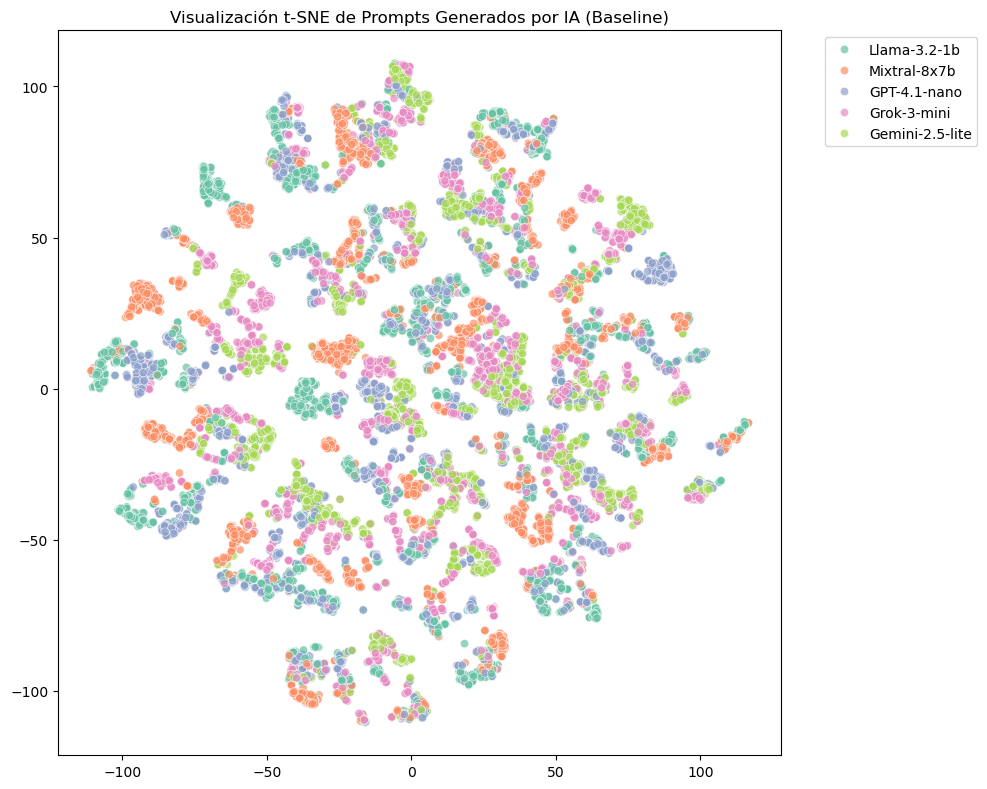

In [6]:
# Usamos TruncatedSVD (el equivalente a PCA para texto disperso)
svd = TruncatedSVD(n_components=50, random_state=42)
X_train_svd = svd.fit_transform(X_train_hybrid)

# Aplicamos t-SNE sobre el resultado de SVD para visualizar en 2D
# (Hacer t-SNE directo sobre TF-IDF tardaría muchísimo)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_train_svd)

# Gráfico
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne_2d[:, 0], y=X_tsne_2d[:, 1], 
    hue=y_train, palette='Set2', alpha=0.7
)
plt.title("Visualización t-SNE de Prompts Generados por IA (Baseline)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 5: Entrenamiento y Evaluación de Modelos


🤖 ENTRENANDO: Multinomial Naive Bayes

📊 MÉTRICAS EN TRAIN (Entrenamiento):
--------------------------------------------------
                 precision    recall  f1-score   support

   GPT-4.1-nano       0.98      0.94      0.96      3570
Gemini-2.5-lite       0.95      0.96      0.96      3565
    Grok-3-mini       0.97      0.99      0.98      3571
   Llama-3.2-1b       0.97      0.95      0.96      3565
   Mixtral-8x7b       0.95      0.98      0.96      3571

       accuracy                           0.96     17842
      macro avg       0.96      0.96      0.96     17842
   weighted avg       0.96      0.96      0.96     17842


🎯 MÉTRICAS EN TEST (Evaluación / OOD):
--------------------------------------------------
                 precision    recall  f1-score   support

   GPT-4.1-nano       0.91      0.82      0.86       315
Gemini-2.5-lite       0.80      1.00      0.89       316
    Grok-3-mini       0.92      0.94      0.93       317
   Llama-3.2-1b       0.93      0.76

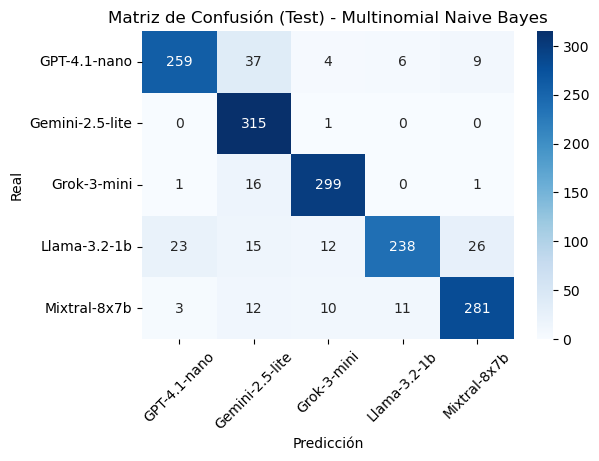


🤖 ENTRENANDO: Linear SVM

📊 MÉTRICAS EN TRAIN (Entrenamiento):
--------------------------------------------------
                 precision    recall  f1-score   support

   GPT-4.1-nano       1.00      1.00      1.00      3570
Gemini-2.5-lite       1.00      1.00      1.00      3565
    Grok-3-mini       1.00      1.00      1.00      3571
   Llama-3.2-1b       1.00      1.00      1.00      3565
   Mixtral-8x7b       1.00      1.00      1.00      3571

       accuracy                           1.00     17842
      macro avg       1.00      1.00      1.00     17842
   weighted avg       1.00      1.00      1.00     17842


🎯 MÉTRICAS EN TEST (Evaluación / OOD):
--------------------------------------------------
                 precision    recall  f1-score   support

   GPT-4.1-nano       0.97      0.87      0.92       315
Gemini-2.5-lite       0.85      0.98      0.91       316
    Grok-3-mini       1.00      0.92      0.96       317
   Llama-3.2-1b       0.88      0.94      0.90   

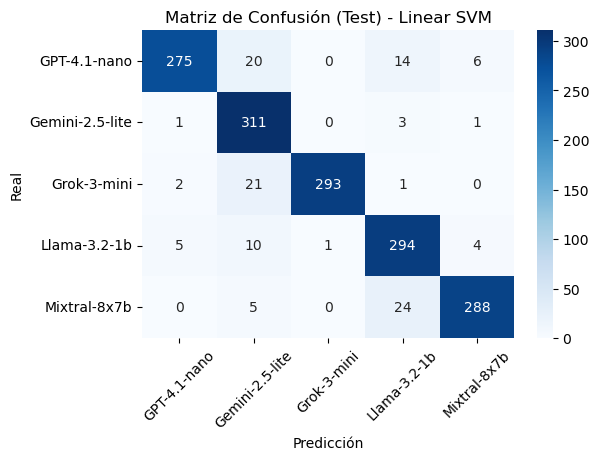

In [7]:
# ==========================================
# 5. MACHINE LEARNING BASELINE (NAIVE BAYES & SVM)
# ==========================================

def train_and_evaluate(model, name, X_train, y_train, X_test, y_test):
    print(f"\n{'='*50}")
    print(f"🤖 ENTRENANDO: {name}")
    print(f"{'='*50}")
    
    # 1. Entrenamos el modelo
    model.fit(X_train, y_train)
    
    # 2. Predicciones y Métricas en TRAIN
    y_pred_train = model.predict(X_train)
    print("\n📊 MÉTRICAS EN TRAIN (Entrenamiento):")
    print("--------------------------------------------------")
    print(classification_report(y_train, y_pred_train))
    
    # 3. Predicciones y Métricas en TEST
    y_pred_test = model.predict(X_test)
    print("\n🎯 MÉTRICAS EN TEST (Evaluación / OOD):")
    print("--------------------------------------------------")
    print(classification_report(y_test, y_pred_test))
    
    # 4. Matriz de Confusión (Mantenemos la visualización solo para el Test)
    cm = confusion_matrix(y_test, y_pred_test, labels=model.classes_)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Matriz de Confusión (Test) - {name}")
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.xticks(rotation=45)
    plt.show()

# 1. Multinomial Naive Bayes
nb_model = MultinomialNB()
train_and_evaluate(nb_model, "Multinomial Naive Bayes", X_train_hybrid, y_train, X_test_hybrid, y_test)

# 2. Support Vector Machine (Kernel Lineal)
svm_model = LinearSVC(random_state=42, class_weight='balanced', dual=False)
train_and_evaluate(svm_model, "Linear SVM", X_train_hybrid, y_train, X_test_hybrid, y_test)

In [8]:
# Recuperamos todos los nombres de las columnas (palabras y n-gramas)
features_word = vectorizer_word.get_feature_names_out()
features_ngram = vectorizer_ngram.get_feature_names_out()
all_features = np.concatenate([features_word, features_ngram])

# Extraemos los coeficientes del SVM
print("--- TOP 10 PALABRAS/N-GRAMAS MÁS DECISIVOS POR IA ---")
for i, model_name in enumerate(svm_model.classes_):
    # Cogemos los índices de los 10 coeficientes más altos para esta clase
    top_indices = np.argsort(svm_model.coef_[i])[-10:]
    top_features = [all_features[j] for j in top_indices]
    
    print(f"\n🤖 {model_name}:")
    print(" | ".join(top_features))

--- TOP 10 PALABRAS/N-GRAMAS MÁS DECISIVOS POR IA ---

🤖 GPT-4.1-nano:
especially | overall | summary boldtag newlinetag | include newlinetag numlisttag | in summary | newlinetag numlisttag boldtag | numlisttag boldtag | summary boldtag | summary | certainly

🤖 Gemini-2.5-lite:
of | multifaceted | directly | boldtag | their | chopped | direct | this | boldtag newlinetag newlinetag | boldtag while

🤖 Grok-3-mini:
which | from | for instance | or | in | for | ill | below | below ill | like

🤖 Llama-3.2-1b:
some common | numlisttag boldtag increased | with roasted | you re | including | boldtag newlinetag numlisttag | such as | such | boldtag | boldtag newlinetag newlinetag

🤖 Mixtral-8x7b:
there | also | important to | sure | remember | can | newlinetag remember | newlinetag newlinetag remember | numlisttag | newlinetag numlisttag


In [9]:
# Volvemos a generar las predicciones del test
y_pred_svm = svm_model.predict(X_test_hybrid)

# Encontramos los índices donde la predicción no coincide con la realidad
errores_idx = (y_test != y_pred_svm)

# Creamos un DataFrame solo con los errores para inspeccionarlos
df_errores = pd.DataFrame({
    'Texto Real': X_test[errores_idx].values,
    'IA Verdadera': y_test[errores_idx].values,
    'Predicción SVM': y_pred_svm[errores_idx]
})

print(f"Total de errores cometidos: {len(df_errores)} de {len(y_test)} textos")
if len(df_errores) > 0:
    print("\n--- EJEMPLOS DE ERRORES ---")
    # Mostramos los primeros 5 errores completos
    for i in range(min(10, len(df_errores))):
        print(f"\n❌ Caso {i+1}:")
        print(f"  Verdadero:  {df_errores.iloc[i]['IA Verdadera']}")
        print(f"  Predicho:   {df_errores.iloc[i]['Predicción SVM']}")
        # Imprimimos los primeros 200 caracteres del texto para no saturar la pantalla
        print(f"  Texto:      {df_errores.iloc[i]['Texto Real'][:200]}...")

Total de errores cometidos: 118 de 1579 textos

--- EJEMPLOS DE ERRORES ---

❌ Caso 1:
  Verdadero:  Mixtral-8x7b
  Predicho:   Llama-3.2-1b
  Texto:      human settlement on mars is a complex issue that involves overcoming numerous challenges to ensure longterm sustainability . here are some of the primary challenges newlinetag numlisttag boldtag envir...

❌ Caso 2:
  Verdadero:  Llama-3.2-1b
  Predicho:   Mixtral-8x7b
  Texto:      the primary purpose of the international space stations solar power system is to generate electricity for the station using solar panels . the solar power system is designed to harness the energy from...

❌ Caso 3:
  Verdadero:  GPT-4.1-nano
  Predicho:   Gemini-2.5-lite
  Texto:      the primary purpose of the international space stations iss solar power system is to generate electrical power to support the stations operations and systems . the solar panels convert sunlight into e...

❌ Caso 4:
  Verdadero:  Mixtral-8x7b
  Predicho:   Gemini-2.5-lite
  Te

In [10]:
# Definimos las "muletillas de formato" que descubrimos que le daban ventaja
trampas_formato = ['newlinetag', 'boldtag', 'numlisttag', 'summary', 'heres', 'remember']

# Creamos nuevos vectorizadores ignorando explícitamente estas palabras
vec_word_blind = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=5000, stop_words=trampas_formato)
vec_ngram_blind = TfidfVectorizer(analyzer='word', ngram_range=(2, 3), max_features=5000, stop_words=trampas_formato)

# Transformamos solo el Train para hacer una prueba rápida
X_train_blind = hstack([
    vec_word_blind.fit_transform(X_train),
    vec_ngram_blind.fit_transform(X_train)
])
X_test_blind = hstack([
    vec_word_blind.transform(X_test),
    vec_ngram_blind.transform(X_test)
])

# Entrenamos un SVM "Ciego" a los formatos
svm_blind = LinearSVC(random_state=42, class_weight='balanced', dual=False)
svm_blind.fit(X_train_blind, y_train)
score_blind = svm_blind.score(X_test_blind, y_test)

print(f"Precisión del SVM Original (con formato): 0.93") 
print(f"Precisión del SVM 'Ciego' (sin formato):  {score_blind:.4f}")

Precisión del SVM Original (con formato): 0.93
Precisión del SVM 'Ciego' (sin formato):  0.8543
